In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, top_k_accuracy_score
import lightgbm as lgb
import time

df = pd.read_csv("dispatch_enriched.csv")

df["service_category"] = df["service_category"].astype(str)
df["weather"] = df["weather"].astype(str)

In [ ]:
feature_cols = [
    'pickup_lat','pickup_lon','drop_lat','drop_lon','distance_km',
    'booking_value','skill_match_score','driver_avg_rating','customer_repeat_rate',
    'traffic_index','temp','humidity','peak_hour',
    'service_category','weather'
]

df_features = df[feature_cols]

df_features = pd.get_dummies(df_features, columns=['service_category', 'weather'], drop_first=True)

le = LabelEncoder()
y = le.fit_transform(df['best_driver_id'])

X = df_features
print("Final feature shape:", X.shape)


Final feature shape: (93000, 24)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)


(74400, 24) (18600, 24)


In [ ]:
model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(np.unique(y)),
    boosting_type='gbdt',
    learning_rate=0.1,
    n_estimators=300,
    max_depth=12,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.2,
    reg_alpha=0.4,
    n_jobs=-1
)

print("Training LightGBM (CPU)...")
t0 = time.time()
model.fit(X_train, y_train)
t1 = time.time()

print("Training time:", round(t1 - t0, 2), "seconds")


Training LightGBM (CPU)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007640 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2027
[LightGBM] [Info] Number of data points in the train set: 74400, number of used features: 23
[LightGBM] [Info] Start training from score -5.728273
[LightGBM] [Info] Start training from score -5.695750
[LightGBM] [Info] Start training from score -5.728273
[LightGBM] [Info] Start training from score -5.664252
[LightGBM] [Info] Start training from score -5.622500
[LightGBM] [Info] Start training from score -5.695750
[LightGBM] [Info] Start training from score -5.656530
[LightGBM] [Info] Start training from score -5.728273
[LightGBM] [Info] Start training from score -5.728273
[LightGBM] [Info] Start training from score -5.604083
[LightGBM] [Info] Start training from score -5.720043
[LightGBM] [Info] Start training from score -5.660383
[LightGBM] [Info] Start training fro

In [16]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
top3 = top_k_accuracy_score(y_test, y_prob, k=3)

print("Accuracy:", acc)
print("Macro F1:", f1)
print("Top-3 Accuracy:", top3)

Accuracy: 0.8634408602150537
Macro F1: 0.8632938091625454
Top-3 Accuracy: 0.9990322580645161


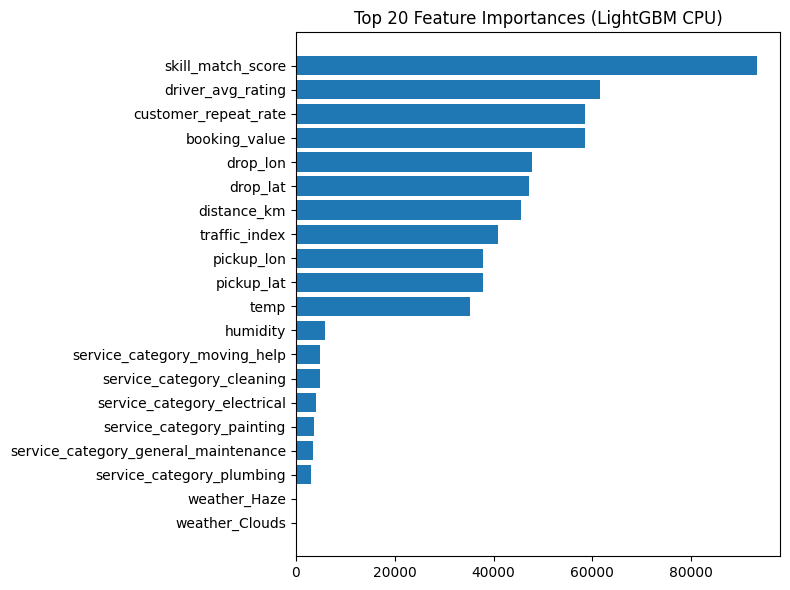

In [17]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,6))
plt.barh(X.columns[indices][:20][::-1], importances[indices][:20][::-1])
plt.title("Top 20 Feature Importances (LightGBM CPU)")
plt.tight_layout()
plt.show()


In [ ]:
import joblib
joblib.dump(model, "dispatch_lightgbm_cpu.pkl")
joblib.dump(le, "driver_label_encoder.pkl")
print("Model saved!")

Model saved!
